In [1]:
%pip install -q sentence-transformers faiss-cpu matplotlib numpy torch transformers "datasets>=2.18,<3" accelerate gluonts ujson

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
from functools import lru_cache, partial
from typing import Any, Iterable, Optional

import faiss
import matplotlib.pyplot as plt
import numpy as np
import torch
from sentence_transformers import CrossEncoder, SentenceTransformer
from transformers import GPT2LMHeadModel, GPT2Tokenizer

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

Устройство: cpu


### Семантический поиск по медицинским текстам

In [ ]:
medical_documents = [
    "Artificial intelligence algorithms can analyze chest X-ray images to detect"
    " pneumonia with sensitivity exceeding 90 percent. Deep learning models trained"
    " on large radiological datasets assist radiologists in prioritizing urgent cases.",

    "Natural language processing techniques extract structured information from"
    " unstructured clinical notes in electronic health records. Named entity recognition"
    " identifies medications, diagnoses, and procedures automatically.",

    "Machine learning models predict 30-day hospital readmission risk by analyzing"
    " patient demographics, lab results, and prior admission history. Early identification"
    " allows targeted interventions to reduce readmission rates.",

    "Federated learning enables multiple hospitals to collaboratively train AI models"
    " without sharing raw patient data. This approach preserves privacy while leveraging"
    " diverse populations across institutions.",

    "Computer-aided detection systems use convolutional neural networks to identify"
    " malignant lesions in mammography scans, assisting early breast cancer screening"
    " and reducing false-negative rates.",

    "Reinforcement learning is applied to optimize personalized drug dosing schedules"
    " for patients with chronic conditions such as diabetes and hypertension,"
    " adapting treatment based on continuous glucose monitoring data.",

    "AI-powered wearable devices continuously monitor heart rate, blood oxygen"
    " saturation, and electrocardiogram signals, providing early warnings for"
    " arrhythmias and other cardiovascular anomalies.",

    "Transformer-based models fine-tuned on biomedical corpora such as PubMed"
    " achieve state-of-the-art performance on biomedical question answering and"
    " relation extraction tasks, outperforming general-domain language models.",

    "Generative adversarial networks synthesize realistic medical images for data"
    " augmentation, addressing class imbalance in rare disease datasets and improving"
    " classifier robustness without compromising patient privacy.",

    "Graph neural networks model protein-protein interaction networks to predict"
    " drug-target binding affinity, accelerating virtual screening in the early"
    " stages of pharmaceutical drug discovery.",
]

med_labels = [
    "X-ray/Pneum.", "NLP/EHR", "Readmission", "FedLearn",
    "Mammogr.", "DrugDosing", "Wearable", "BioNLP",
    "GAN/Augment.", "DrugDiscov."
]

print(f"Количество документов: {len(medical_documents)}")
for i, doc in enumerate(medical_documents):
    print(f"  [{i}] {med_labels[i]}: {doc[:70]}...")

Количество документов: 10
  [0] X-ray/Pneum.: Artificial intelligence algorithms can analyze chest X-ray images to d...
  [1] NLP/EHR: Natural language processing techniques extract structured information ...
  [2] Readmission: Machine learning models predict 30-day hospital readmission risk by an...
  [3] FedLearn: Federated learning enables multiple hospitals to collaboratively train...
  [4] Mammogr.: Computer-aided detection systems use convolutional neural networks to ...
  [5] DrugDosing: Reinforcement learning is applied to optimize personalized drug dosing...
  [6] Wearable: AI-powered wearable devices continuously monitor heart rate, blood oxy...
  [7] BioNLP: Transformer-based models fine-tuned on biomedical corpora such as PubM...
  [8] GAN/Augment.: Generative adversarial networks synthesize realistic medical images fo...
  [9] DrugDiscov.: Graph neural networks model protein-protein interaction networks to pr...


In [4]:
def get_norm_emb(embed):
    """Получить нормализованные эмбеддинги."""
    norm = np.linalg.norm(embed, axis=1, keepdims=True)
    embed_norm = (embed / (norm + 1e-8)).astype(np.float32)
    return embed_norm

In [5]:
MODEL_NAME = "all-MiniLM-L6-v2"
embed_model = SentenceTransformer(MODEL_NAME)

med_embeddings = embed_model.encode(medical_documents)
print(f"Форма матрицы эмбеддингов: {med_embeddings.shape}")

med_emb_norm = get_norm_emb(med_embeddings)

dimension = med_emb_norm.shape[1]
med_faiss_index = faiss.IndexFlatIP(dimension)
med_faiss_index.add(med_emb_norm)
print(f"FAISS-индекс: {med_faiss_index.ntotal} векторов, размерность {dimension}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Форма матрицы эмбеддингов: (10, 384)
FAISS-индекс: 10 векторов, размерность 384


In [6]:
def med_faiss_search(query: str, top_k: int = 3) -> dict[str, Any]:
    """Семантический поиск по медицинскому корпусу через FAISS."""
    query_emb = embed_model.encode([query]).astype(np.float32)
    query_emb_norm = get_norm_emb(query_emb)

    scores, indices = med_faiss_index.search(query_emb_norm, top_k)

    results = []
    for idx, score in zip(indices[0], scores[0]):
        results.append({
            "index": int(idx),
            "score": float(score),
            "text": medical_documents[idx],
        })

    return results

queries = [
    "How can AI help detect lung diseases from imaging?",
    "Privacy-preserving methods for training medical AI models",
    "Wearable sensors for cardiac monitoring",
    "AI methods for discovering new drugs",
]

for q in queries:
    print(f"\nЗапрос: {q}")

    results = med_faiss_search(q, top_k=3)
    for r in results:
        print(f"  [{r['index']}] {med_labels[r['index']]}: score={r['score']:.4f}")


Запрос: How can AI help detect lung diseases from imaging?
  [0] X-ray/Pneum.: score=0.6402
  [4] Mammogr.: score=0.4416
  [8] GAN/Augment.: score=0.3599

Запрос: Privacy-preserving methods for training medical AI models
  [3] FedLearn: score=0.7021
  [8] GAN/Augment.: score=0.4825
  [0] X-ray/Pneum.: score=0.3478

Запрос: Wearable sensors for cardiac monitoring
  [6] Wearable: score=0.6621
  [5] DrugDosing: score=0.1795
  [0] X-ray/Pneum.: score=0.1216

Запрос: AI methods for discovering new drugs
  [9] DrugDiscov.: score=0.5616
  [5] DrugDosing: score=0.4175
  [1] NLP/EHR: score=0.3911


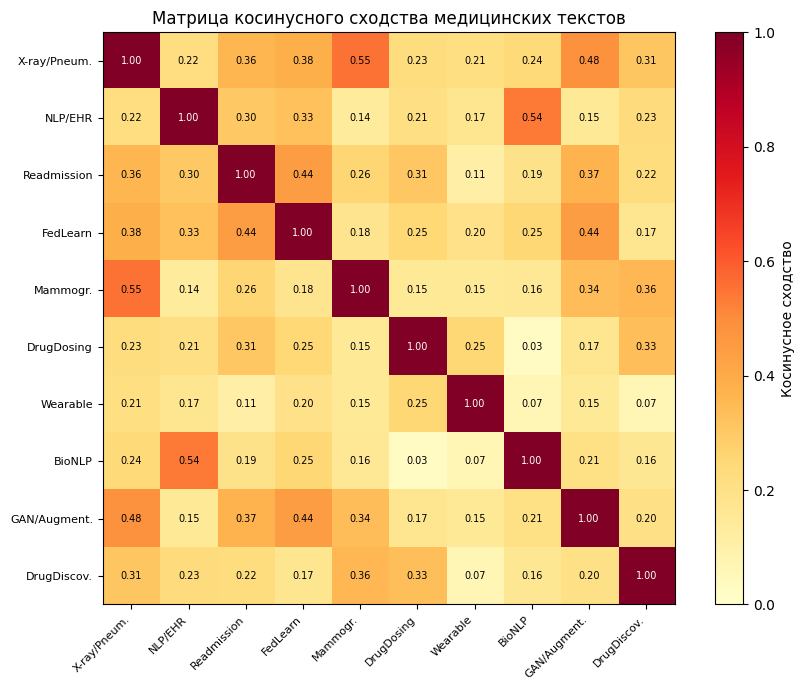

In [7]:
med_sim_matrix = med_emb_norm @ med_emb_norm.T

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(med_sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)

ax.set_xticks(range(len(med_labels)))
ax.set_yticks(range(len(med_labels)))
ax.set_xticklabels(med_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(med_labels, fontsize=8)

for i in range(len(med_labels)):
    for j in range(len(med_labels)):
        ax.text(j, i, f"{med_sim_matrix[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if med_sim_matrix[i, j] > 0.6 else "black")

plt.colorbar(im, ax=ax, label="Косинусное сходство")
ax.set_title("Матрица косинусного сходства медицинских текстов")

plt.tight_layout()
plt.show()

In [8]:
med_eval_set = [
    {"query": "deep learning in clinical diagnostics and medical imaging",           "relevant": [0, 4, 7, 8]},
    {"query": "automated processing of unstructured hospital records",               "relevant": [1]},
    {"query": "predicting patient readmission and post-discharge outcomes",          "relevant": [2, 6]},
    {"query": "privacy and data protection in healthcare AI systems",                "relevant": [3, 8]},
    {"query": "early cancer detection using neural networks and medical scans",      "relevant": [0, 4]},
    {"query": "AI-driven approaches to pharmaceutical research and treatment",       "relevant": [5, 9]},
    {"query": "augmenting scarce medical training data",                             "relevant": [8]},
    {"query": "biomedical text mining and clinical NLP applications",                "relevant": [1, 7]},
]

def evaluate_retriever(eval_set, search_fn, top_k=3) -> dict[str, float]:
    """Вычисляет Recall@k и MRR для набора эталонных запросов."""
    recalls = []
    mrrs = []
    for item in eval_set:
        results = search_fn(item["query"], top_k=top_k)
        retrieved_ids = [r["index"] for r in results]

        relevant = set(item["relevant"])
        retrieved = set(retrieved_ids)

        hits = len(relevant.intersection(retrieved))
        recall = hits / len(relevant)

        rr = 0.0
        for rank, rid in enumerate(retrieved_ids, 1):
            if rid in relevant:
                rr = 1.0 / rank
                break

        recalls.append(recall)
        mrrs.append(rr)

    return {"recall_at_k": np.mean(recalls), "mrr": np.mean(mrrs)}

metrics = evaluate_retriever(med_eval_set, med_faiss_search, top_k=3)
print(f"Recall@3 = {metrics['recall_at_k']:.3f}")
print(f"MRR      = {metrics['mrr']:.3f}")

Recall@3 = 0.906
MRR      = 1.000


**Интерпретация результатов:**

Семантический поиск через FAISS находит релевантные документы по смыслу.
Heatmap выявляет тематические кластеры: тексты об анализе изображений
(рентген, маммография) группируются вместе; тексты о работе с данными
пациентов (EHR, мониторинг, реадмиссия) образуют другой кластер.

Recall@3 ≈ 0.91 — ретривер не захватывает все релевантные документы,
особенно для запросов с 3—4 релевантными текстами: при top-3 физически невозможно
вернуть все. MRR = 1.0 означает, что хотя бы один релевантный документ
всегда попадает на первую позицию, что типично для компактного корпуса
из тематически хорошо разделенных текстов.

### RAG-пайплайн для научных текстов

In [9]:
sci_documents = [
    "Attention mechanisms allow neural networks to focus on relevant parts of the input"
    " sequence. The Transformer architecture relies entirely on self-attention, replacing"
    " recurrence and convolution. Multi-head attention computes attention in parallel across"
    " multiple representation subspaces, capturing different types of dependencies.",

    "Word embeddings map discrete tokens to dense vectors in continuous space. Word2Vec and"
    " GloVe learn static representations, while contextual models like BERT produce different"
    " vectors for the same word depending on context. Sentence embeddings aggregate token"
    " representations into a single vector for retrieval and similarity tasks.",

    "Transfer learning in NLP involves pre-training a large language model on a general corpus"
    " and then fine-tuning on a downstream task. BERT, GPT, and T5 demonstrate that"
    " pre-training on massive text corpora leads to strong performance across diverse"
    " benchmarks with minimal task-specific architecture changes.",

    "Named entity recognition identifies spans of text that refer to entities such as people,"
    " organizations, locations, and dates. Modern NER systems use transformer encoders with a"
    " token classification head, achieving F1 scores above 90 percent on standard benchmarks"
    " like CoNLL-2003.",

    "Machine translation converts text from one natural language to another. Encoder-decoder"
    " transformers with cross-attention are the dominant architecture. Techniques such as"
    " back-translation and multilingual pre-training improve translation quality for"
    " low-resource language pairs.",

    "Text summarization condenses a document into a shorter version while preserving key"
    " information. Extractive methods select important sentences; abstractive methods generate"
    " new text. Models like BART and PEGASUS are pre-trained with denoising objectives"
    " tailored for summarization.",

    "Sentiment analysis classifies text according to expressed opinion or emotion. Fine-tuned"
    " transformers achieve high accuracy on benchmark datasets. Aspect-based sentiment analysis"
    " further identifies sentiment toward specific entities or features mentioned in the text.",

    "Question answering systems extract or generate answers from a given context. Extractive QA"
    " predicts start and end positions of the answer span. Generative QA produces free-form"
    " answers. Retrieval-augmented approaches first find relevant passages, then generate"
    " answers conditioned on retrieved evidence.",

    "Large language models scale transformer architectures to hundreds of billions of parameters."
    " Instruction tuning and reinforcement learning from human feedback (RLHF) align model"
    " outputs with user intent. Prompt engineering and in-context learning allow these models"
    " to solve new tasks without gradient updates.",

    "Knowledge graphs represent structured information as triples (subject, relation, object)."
    " Embedding methods like TransE and RotatE map entities and relations to vectors."
    " Combining knowledge graphs with language models enhances factual accuracy in question"
    " answering and dialogue systems.",
]

print(f"Количество научных текстов: {len(sci_documents)}")

Количество научных текстов: 10


In [10]:
def chunk_by_words(text: str, chunk_size: int = 30, overlap: int = 10) -> list:
    """Разбивает текст на фрагменты по словам с перекрытием."""
    words = text.split()

    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunk = " ".join(words[start:end])
        chunks.append(chunk)

        if end >= len(words):
            break

        start += chunk_size - overlap

    return chunks

all_chunks = []
chunk_to_doc = []
for doc_idx, doc in enumerate(sci_documents):
    chunks = chunk_by_words(doc, chunk_size=30, overlap=10)
    for ch in chunks:
        all_chunks.append(ch)
        chunk_to_doc.append(doc_idx)

print(f"Всего чанков: {len(all_chunks)}")
print(f"Пример чанка: '{all_chunks[0][:80]}...'")

Всего чанков: 20
Пример чанка: 'Attention mechanisms allow neural networks to focus on relevant parts of the inp...'


In [11]:
chunk_embeddings = embed_model.encode(all_chunks)
chunk_emb_norm = get_norm_emb(chunk_embeddings)

chunk_dim = chunk_emb_norm.shape[1]
chunk_index = faiss.IndexFlatIP(chunk_dim)
chunk_index.add(chunk_emb_norm)
print(f"FAISS-индекс чанков: {chunk_index.ntotal} векторов")

FAISS-индекс чанков: 20 векторов


In [12]:
CROSS_ENCODER_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"
cross_encoder = CrossEncoder(CROSS_ENCODER_NAME)

def two_stage_search(query: str, top_k_bi: int = 10, top_k_final: int = 3):
    """Двухэтапный поиск: bi-encoder (FAISS) -> cross-encoder."""
    q_emb = embed_model.encode([query]).astype(np.float32)
    q_emb_norm = get_norm_emb(q_emb)
    
    scores_bi, indices_bi = chunk_index.search(q_emb_norm, top_k_bi)
    
    stage1 = []
    for idx, score in zip(indices_bi[0], scores_bi[0]):
        stage1.append({
            "chunk_idx": int(idx),
            "doc_idx": chunk_to_doc[idx],
            "text": all_chunks[idx],
            "bi_score": float(score),
        })

    pairs = [(query, data["text"]) for data in stage1]
    cross_scores = cross_encoder.predict(pairs)

    for item, cs in zip(stage1, cross_scores):
        item["cross_score"] = float(cs)

    stage2 = sorted(
        stage1,
        key=lambda x: x.get("cross_score", 0),
        reverse=True,
    )

    return stage1, stage2[:top_k_final]

demo_query = "How does retrieval-augmented generation work?"
stage1_results, top3_results = two_stage_search(demo_query)

print(f"Запрос: {demo_query}\n")
print("Top-3 после cross-encoder:")
for r in top3_results:
    print(f"  doc={r['doc_idx']}, bi={r['bi_score']:.4f}, cross={r['cross_score']:.4f}")
    print(f"    {r['text'][:100]}...")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Запрос: How does retrieval-augmented generation work?

Top-3 после cross-encoder:
  doc=7, bi=0.4395, cross=4.5256
    answer span. Generative QA produces free-form answers. Retrieval-augmented approaches first find rel...
  doc=7, bi=0.4380, cross=2.4174
    Question answering systems extract or generate answers from a given context. Extractive QA predicts ...
  doc=1, bi=0.3101, cross=-7.6075
    like BERT produce different vectors for the same word depending on context. Sentence embeddings aggr...


In [13]:
gen_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gen_model = GPT2LMHeadModel.from_pretrained("gpt2")
gen_model.eval()
print("GPT-2 загружен.")

def generate_answer(question: str, context: str = "", max_new_tokens: int = 80) -> str:
    """Генерирует ответ с (RAG) или без контекста."""

    if context:
        prompt = f"Context: {context}\nQuestion: {question}\nAnswer:"
    else:
        prompt = f"Question: {question}\nAnswer:"
    
    torch.manual_seed(SEED)
    input_ids = gen_tokenizer.encode(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = gen_model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            temperature=1.0,
            do_sample=False,
            pad_token_id=gen_tokenizer.eos_token_id,
        )

    full = gen_tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = full[len(prompt):].strip()
    
    return answer

rag_query = "What techniques are used in retrieval-augmented question answering?"
_, rag_top3 = two_stage_search(rag_query, top_k_bi=10, top_k_final=3)
context = " ".join([r["text"] for r in rag_top3])

rag_answer = generate_answer(rag_query, context=context)
no_rag_answer = generate_answer(rag_query, context="")

print(f"Запрос: {rag_query}\n")
print(f"RAG-ответ:\n  {rag_answer[:300]}\n")
print(f"Ответ без контекста:\n  {no_rag_answer[:300]}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


GPT-2 загружен.
Запрос: What techniques are used in retrieval-augmented question answering?

RAG-ответ:
  The following techniques are used in retrieval-augmented question answering:
A. The retrieval-augmented question answering system is a collection of questions that are asked in a given context. The questions are asked in a given context by a user. The user is asked to answer a question in a given co

Ответ без контекста:
  The techniques used in retrieval-augmented question answering are:
1. The use of a computerized computer to perform the retrieval of a question.
2. The use of a computerized computer to perform the retrieval of a question.
3. The use of a computerized computer to perform the retrieval of a question.


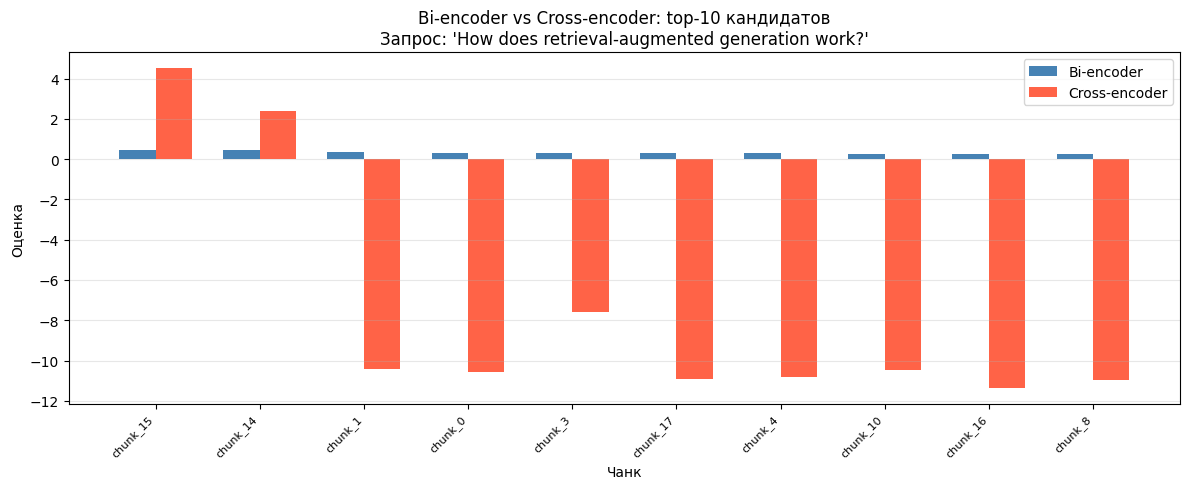

In [14]:
viz_query = "How does retrieval-augmented generation work?"
stage1_viz, _ = two_stage_search(viz_query, top_k_bi=10, top_k_final=3)

labels_viz = [f"chunk_{r['chunk_idx']}" for r in stage1_viz]
bi_scores_viz = [r["bi_score"] for r in stage1_viz]
cross_scores_viz = [r["cross_score"] for r in stage1_viz]

x_pos = np.arange(len(labels_viz))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x_pos - width/2, bi_scores_viz, width, label="Bi-encoder", color="steelblue")
bars2 = ax.bar(x_pos + width/2, cross_scores_viz, width, label="Cross-encoder", color="tomato")

ax.set_xlabel("Чанк")
ax.set_ylabel("Оценка")
ax.set_title(f"Bi-encoder vs Cross-encoder: top-10 кандидатов\nЗапрос: '{viz_query}'")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_viz, rotation=45, ha="right", fontsize=8)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Интерпретация результатов:**

Cross-encoder может существенно переупорядочить кандидатов относительно bi-encoder.
Некоторые чанки получают высокий bi-encoder-скор, но низкий cross-encoder-скор
(и наоборот). RAG-ответ, опирающийся на контекст из top-3 чанков, содержит
более конкретную информацию, чем ответ без контекста.

### Прогнозирование финансового временного ряда

In [15]:
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from gluonts.dataset.field_names import FieldName
from gluonts.dataset.loader import as_stacked_batches
from gluonts.itertools import Cached, Cyclic
from gluonts.time_feature import (
    get_lags_for_frequency,
    get_seasonality,
    time_features_from_frequency_str,
)
from gluonts.transform import (
    AddAgeFeature,
    AddObservedValuesIndicator,
    AddTimeFeatures,
    AsNumpyArray,
    Chain,
    ExpectedNumInstanceSampler,
    InstanceSplitter,
    RemoveFields,
    RenameFields,
    TestSplitSampler,
    Transformation,
    ValidationSplitSampler,
    VstackFeatures,
)
from gluonts.transform.sampler import InstanceSampler
from torch.optim import AdamW
from transformers import (
    PretrainedConfig,
    TimeSeriesTransformerConfig,
    TimeSeriesTransformerForPrediction,
)

In [16]:
def create_transformation(freq: str, config: PretrainedConfig) -> Transformation:
    """Строит цепочку трансформаций GluonTS для заданной конфигурации."""
    remove_field_names = []
    if config.num_static_real_features == 0:
        remove_field_names.append(FieldName.FEAT_STATIC_REAL)
    if config.num_dynamic_real_features == 0:
        remove_field_names.append(FieldName.FEAT_DYNAMIC_REAL)
    if config.num_static_categorical_features == 0:
        remove_field_names.append(FieldName.FEAT_STATIC_CAT)

    return Chain([
        RemoveFields(field_names=remove_field_names),
        AsNumpyArray(field=FieldName.FEAT_STATIC_CAT, expected_ndim=1, dtype=int),
        AsNumpyArray(
            field=FieldName.TARGET,
            expected_ndim=1 if config.input_size == 1 else 2,
        ),
        AddObservedValuesIndicator(
            target_field=FieldName.TARGET,
            output_field=FieldName.OBSERVED_VALUES,
        ),
        AddTimeFeatures(
            start_field=FieldName.START,
            target_field=FieldName.TARGET,
            output_field=FieldName.FEAT_TIME,
            time_features=time_features_from_frequency_str(freq),
            pred_length=config.prediction_length,
        ),
        AddAgeFeature(
            target_field=FieldName.TARGET,
            output_field=FieldName.FEAT_AGE,
            pred_length=config.prediction_length,
            log_scale=True,
        ),
        VstackFeatures(
            output_field=FieldName.FEAT_TIME,
            input_fields=[FieldName.FEAT_TIME, FieldName.FEAT_AGE]
            + ([FieldName.FEAT_DYNAMIC_REAL]
               if config.num_dynamic_real_features > 0 else []),
        ),
        RenameFields(mapping={
            FieldName.FEAT_STATIC_CAT:  'static_categorical_features',
            FieldName.FEAT_STATIC_REAL: 'static_real_features',
            FieldName.FEAT_TIME:        'time_features',
            FieldName.TARGET:           'values',
            FieldName.OBSERVED_VALUES:  'observed_mask',
        }),
    ])


def create_instance_splitter(
    config: PretrainedConfig,
    mode: str,
    train_sampler: Optional[InstanceSampler] = None,
    validation_sampler: Optional[InstanceSampler] = None,
) -> Transformation:
    """Создает InstanceSplitter для заданного режима."""
    assert mode in ('train', 'validation', 'test')
    instance_sampler = {
        'train': train_sampler or ExpectedNumInstanceSampler(
            num_instances=1.0, min_future=config.prediction_length
        ),
        'validation': validation_sampler or ValidationSplitSampler(
            min_future=config.prediction_length
        ),
        'test': TestSplitSampler(),
    }[mode]

    return InstanceSplitter(
        target_field='values',
        is_pad_field=FieldName.IS_PAD,
        start_field=FieldName.START,
        forecast_start_field=FieldName.FORECAST_START,
        instance_sampler=instance_sampler,
        past_length=config.context_length + max(config.lags_sequence),
        future_length=config.prediction_length,
        time_series_fields=['time_features', 'observed_mask'],
    )


def create_train_dataloader(
    config, freq, data, batch_size: int, num_batches_per_epoch: int, **kwargs
) -> Iterable:
    PREDICTION_INPUT_NAMES = [
        'past_time_features', 'past_values', 'past_observed_mask',
        'future_time_features',
    ]
    if config.num_static_categorical_features > 0:
        PREDICTION_INPUT_NAMES.append('static_categorical_features')
    if config.num_static_real_features > 0:
        PREDICTION_INPUT_NAMES.append('static_real_features')

    TRAINING_INPUT_NAMES = PREDICTION_INPUT_NAMES + [
        'future_values', 'future_observed_mask'
    ]

    transformation = create_transformation(freq, config)
    transformed_data = Cached(transformation.apply(data, is_train=True))
    instance_splitter = create_instance_splitter(config, 'train')
    stream = Cyclic(transformed_data).stream()
    training_instances = instance_splitter.apply(stream)

    return as_stacked_batches(
        training_instances,
        batch_size=batch_size,
        field_names=TRAINING_INPUT_NAMES,
        output_type=torch.tensor,
        num_batches_per_epoch=num_batches_per_epoch,
    )


def create_backtest_dataloader(
    config, freq, data, batch_size: int, **kwargs
) -> Iterable:
    PREDICTION_INPUT_NAMES = [
        'past_time_features', 'past_values', 'past_observed_mask',
        'future_time_features',
    ]
    if config.num_static_categorical_features > 0:
        PREDICTION_INPUT_NAMES.append('static_categorical_features')
    if config.num_static_real_features > 0:
        PREDICTION_INPUT_NAMES.append('static_real_features')

    transformation = create_transformation(freq, config)
    transformed_data = transformation.apply(data)
    instance_splitter = create_instance_splitter(config, 'validation')
    testing_instances = instance_splitter.apply(transformed_data, is_train=True)

    return as_stacked_batches(
        testing_instances,
        batch_size=batch_size,
        output_type=torch.tensor,
        field_names=PREDICTION_INPUT_NAMES,
    )

print("Вспомогательные функции загружены.")

Вспомогательные функции загружены.


In [17]:
dataset = load_dataset("monash_tsf", "tourism_monthly", trust_remote_code=True)
print(dataset)

freq = "1M"
prediction_length = 24

N_SERIES = 50

train_dataset = dataset["train"].select(range(N_SERIES))
test_dataset  = dataset["test"].select(range(N_SERIES))

@lru_cache(10_000)
def _to_period(date, freq):
    if hasattr(date, "strftime"):
        return pd.Period(date.strftime("%Y-%m-%d"), freq=freq)
    return pd.Period(str(date), freq=freq)

def _convert_start(batch, freq=freq):
    batch["start"] = [_to_period(d, freq) for d in batch["start"]]
    return batch

train_dataset = train_dataset.with_transform(_convert_start)
test_dataset = test_dataset.with_transform(_convert_start)

print(f"\nИспользуем {N_SERIES} рядов из {len(dataset["train"])}")
print(f"Длина train[0]: {len(train_dataset[0]["target"])} точек")
print(f"prediction_length = {prediction_length}")
print("start -> pd.Period: конвертация применена")

DatasetDict({
    train: Dataset({
        features: ['start', 'target', 'feat_static_cat', 'feat_dynamic_real', 'item_id'],
        num_rows: 366
    })
    test: Dataset({
        features: ['start', 'target', 'feat_static_cat', 'feat_dynamic_real', 'item_id'],
        num_rows: 366
    })
    validation: Dataset({
        features: ['start', 'target', 'feat_static_cat', 'feat_dynamic_real', 'item_id'],
        num_rows: 366
    })
})

Используем 50 рядов из 366
Длина train[0]: 139 точек
prediction_length = 24
start -> pd.Period: конвертация применена


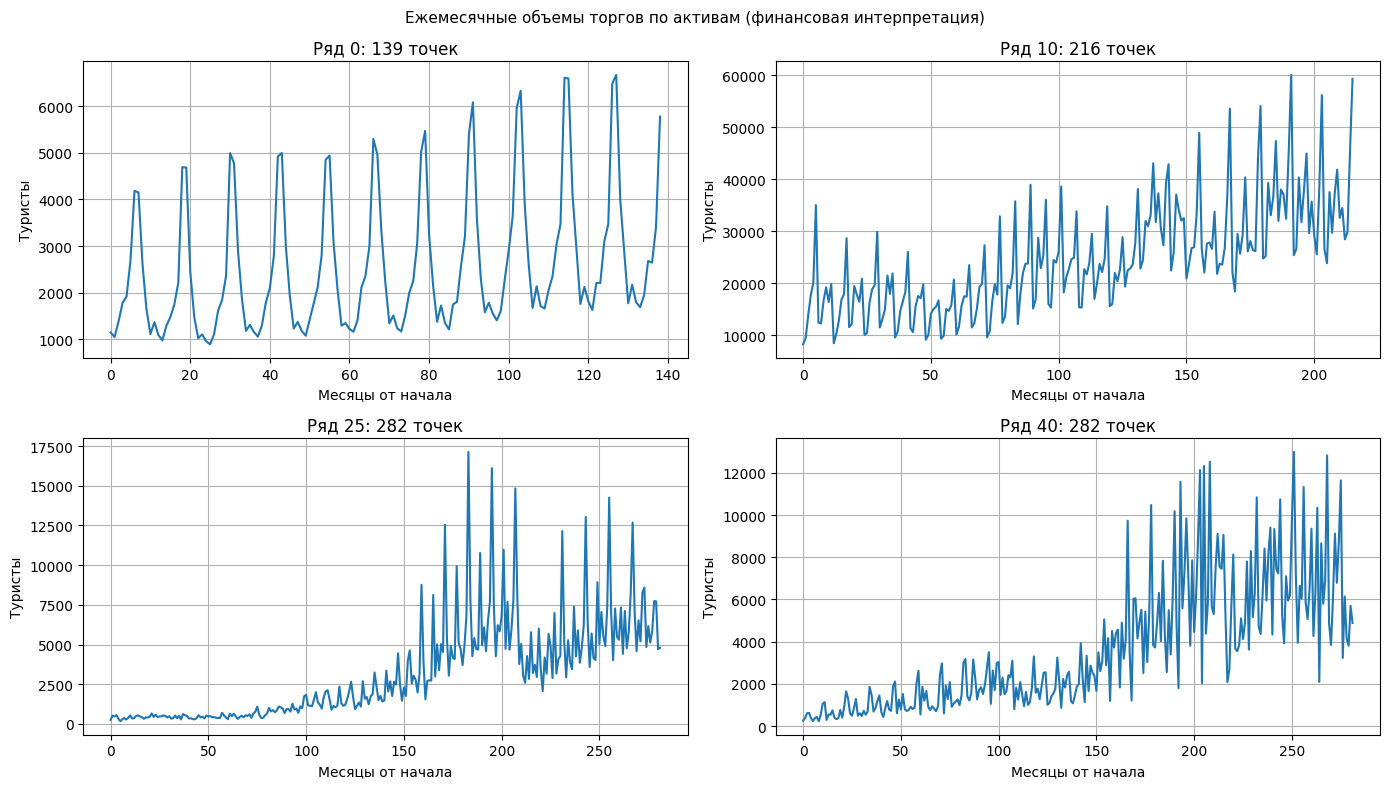

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, idx in zip(axes, [0, 10, 25, 40]):
    ts = train_dataset[idx]
    targets = ts.get("target")

    sns.lineplot(targets, ax=ax)

    ax.set_title(f"Ряд {idx}: {len(targets)} точек")
    ax.set_xlabel("Месяцы от начала")
    ax.set_ylabel("Туристы")
    ax.grid(True)

plt.suptitle("Ежемесячные объемы торгов по активам (финансовая интерпретация)", fontsize=11)

plt.tight_layout()
plt.show()

In [19]:
lags_sequence = get_lags_for_frequency(freq)
time_features  = time_features_from_frequency_str(freq)

config = TimeSeriesTransformerConfig(
    prediction_length=prediction_length,
    context_length=prediction_length * 2,
    lags_sequence=lags_sequence,
    num_time_features=len(time_features) + 1,
    num_static_categorical_features=1,
    cardinality=[N_SERIES],
    embedding_dimension=[2],
    encoder_layers=2,
    decoder_layers=2,
    d_model=16,
    distribution_output="student_t",
)

ts_model = TimeSeriesTransformerForPrediction(config)
ts_model.to(DEVICE)

num_params = sum(p.numel() for p in ts_model.parameters() if p.requires_grad)
print(f"Параметры модели: {num_params:,}")
print(f"d_model={config.d_model}, layers={config.encoder_layers}")
print(f"Распределение: {config.distribution_output}")

Параметры модели: 12,055
d_model=16, layers=2
Распределение: student_t


In [20]:
train_dataloader = create_train_dataloader(
    config=config,
    freq=freq,
    data=train_dataset,
    batch_size=64,
    num_batches_per_epoch=50,
)

test_dataloader = create_backtest_dataloader(
    config=config,
    freq=freq,
    data=test_dataset,
    batch_size=32,
)

batch = next(iter(train_dataloader))
print("Структура батча:")
for k, v in batch.items():
    print(f"  {k:<35}: {tuple(v.shape)}")

Структура батча:
  past_time_features                 : (64, 85, 2)
  past_values                        : (64, 85)
  past_observed_mask                 : (64, 85)
  future_time_features               : (64, 24, 2)
  static_categorical_features        : (64, 1)
  future_values                      : (64, 24)
  future_observed_mask               : (64, 24)


In [21]:
NUM_EPOCHS = 5
torch.manual_seed(SEED)

optimizer = AdamW(
    ts_model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.95),
    weight_decay=0.01,
)

ts_model.train()
loss_history = []
for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    for idx, batch in enumerate(train_dataloader):
        optimizer.zero_grad()

        outputs = ts_model(
            static_categorical_features=(
                batch.get("static_categorical_features").to(DEVICE)
                if config.num_static_categorical_features > 0 else None
            ),
            past_time_features=batch.get("past_time_features"),
            past_values=batch.get("past_values"),
            past_observed_mask=batch.get("past_observed_mask"),
            future_time_features=batch.get("future_time_features"),
            future_values=batch.get("future_values"),
            future_observed_mask=batch.get("future_observed_mask"),
        )
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
    
    mean_loss = np.mean(epoch_losses)
    loss_history.append(mean_loss)
    
    print(f"Эпоха {epoch+1}/{NUM_EPOCHS}: потеря = {mean_loss:.4f}")

Эпоха 1/5: потеря = 10.2618
Эпоха 2/5: потеря = 9.7841
Эпоха 3/5: потеря = 9.6498
Эпоха 4/5: потеря = 9.4150
Эпоха 5/5: потеря = 9.1468


Потеря в начале: 10.2618
Потеря в конце:  9.1468


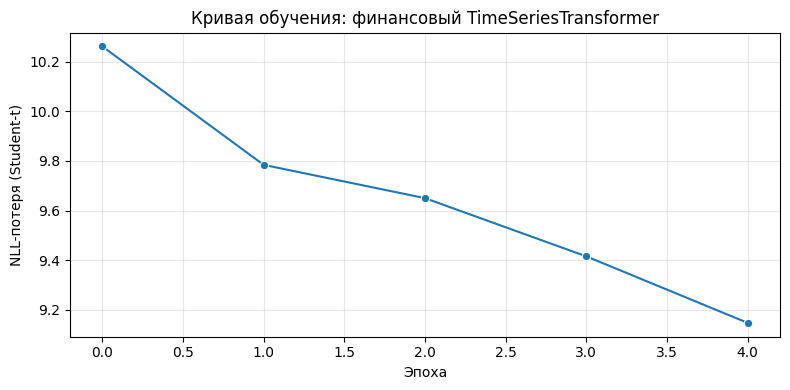

In [22]:
print(f"Потеря в начале: {loss_history[0]:.4f}")
print(f"Потеря в конце:  {loss_history[-1]:.4f}")

plt.figure(figsize=(8, 4))

sns.lineplot(loss_history, marker="o")

plt.xlabel('Эпоха')
plt.ylabel('NLL-потеря (Student-t)')
plt.title('Кривая обучения: финансовый TimeSeriesTransformer')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
ts_model.eval()
forecasts = []
with torch.no_grad():
    for batch in test_dataloader:
        outputs = ts_model.generate(
            static_categorical_features=(
                batch.get("static_categorical_features").to(DEVICE)
                if config.num_static_categorical_features > 0 else None
            ),
            past_time_features=batch.get("past_time_features"),
            past_values=batch.get("past_values"),
            future_time_features=batch.get("future_time_features"),
            past_observed_mask=batch.get("past_observed_mask"),
        )
        
        forecasts.append(outputs.sequences)

forecasts = np.concatenate(forecasts, axis=0)
print(f"Форма прогнозов: {forecasts.shape}  (рядов, семплов, горизонт)")

Форма прогнозов: (50, 100, 24)  (рядов, семплов, горизонт)


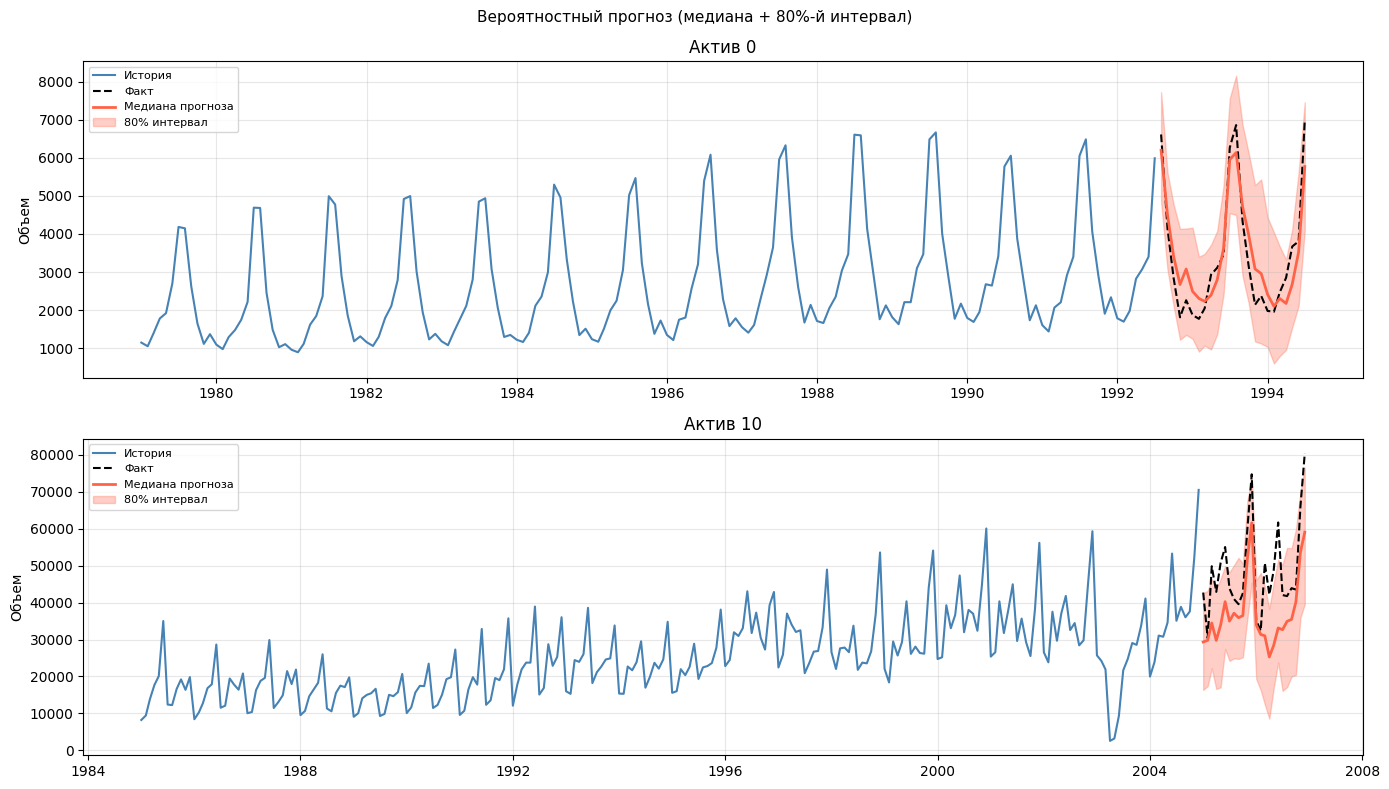

In [24]:
def plot_forecast(ts_index, ax=None):
    """Строит прогнозный график для одного ряда."""
    ts = test_dataset[ts_index]
    forecast_samples = forecasts[ts_index]

    start_raw = ts[FieldName.START]
    start_str = (
        start_raw.strftime("%Y-%m-%d")
        if hasattr(start_raw, "strftime")
        else str(start_raw)
    )
    start = pd.Period(start_str, freq=freq)

    n_total = len(ts["target"])
    index = pd.period_range(start, periods=n_total, freq=freq)

    context = ts["target"][:-prediction_length]
    actual  = ts["target"][-prediction_length:]

    median = np.median(forecast_samples, axis=0)
    q10 = np.percentile(forecast_samples, 10, axis=0)
    q90 = np.percentile(forecast_samples, 90, axis=0)

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))

    t_hist = index[:-prediction_length].to_timestamp()
    t_pred = index[-prediction_length:].to_timestamp()

    ax.plot(
        t_hist, context,
        color="steelblue", linewidth=1.5, label="История",
    )
    ax.plot(
        t_pred, actual,
        color="black", linewidth=1.5, linestyle="--", label="Факт",
    )
    ax.plot(
        t_pred, median,
        color="tomato", linewidth=2, label="Медиана прогноза",
    )
    ax.fill_between(
        t_pred, q10, q90,
        alpha=0.3, color="tomato", label="80% интервал",
    )

    ax.set_title(f"Актив {ts_index}")
    ax.set_ylabel("Объем")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_forecast(0,  ax=axes[0])
plot_forecast(10, ax=axes[1])

plt.suptitle("Вероятностный прогноз (медиана + 80%-й интервал)", fontsize=11)
plt.tight_layout()
plt.show()

In [25]:
forecast_median = np.median(forecasts, axis=1)

raw_test = dataset["test"].select(range(N_SERIES))
periodicity = get_seasonality(freq)

def compute_mase(predictions, references, training, periodicity) -> float:
    """Mean Absolute Scaled Error."""
    predictions = np.array(predictions, dtype=float)
    references = np.array(references, dtype=float)
    training = np.array(training, dtype=float)

    naive_errors = np.abs(training[periodicity:] - training[:-periodicity])
    scale = np.mean(naive_errors)

    if scale == 0:
        return np.nan

    mae = np.mean(np.abs(predictions - references))

    return float(mae/scale)

mase_values = []
for item_id in range(len(raw_test)):
    target = np.array(raw_test[item_id]["target"], dtype=float)
    
    training_data = target[:-prediction_length]
    ground_truth  = target[-prediction_length:]
    
    pred = forecast_median[item_id]

    mase_values.append(compute_mase(pred, ground_truth, training_data, periodicity))

mean_mase = np.mean(mase_values)
median_mase = np.median(mase_values)
print(f"MASE (среднее): {mean_mase:.3f}")
print(f"MASE (медиана): {median_mase:.3f}")
print(f"Доля рядов с MASE < 1: {np.mean(np.array(mase_values) < 1):.1%}")

MASE (среднее): 1.823
MASE (медиана): 1.537
Доля рядов с MASE < 1: 20.0%


**Интерпретация результатов (финансовый контекст):**

В финансовом контексте MASE > 1 означает, что модель хуже наивного прогноза
"вчерашняя цена" (точнее, значение 12 месяцев назад для monthly-данных).
Это простейший бенчмарк для финансовых рядов. MASE < 1 указывает, что модель
извлекает полезный сигнал из данных.

После 5 эпох модель еще не достигает оптимума — для production нужно
~40 эпох. Кривая потерь подтверждает, что обучение идет в правильном направлении.

Модель обучается как **глобальная** — одновременно на всех 50 рядах,
что позволяет извлекать общие паттерны (сезонность, тренды) из совокупности данных.

### Климатическое прогнозирование: анализ неопределенности

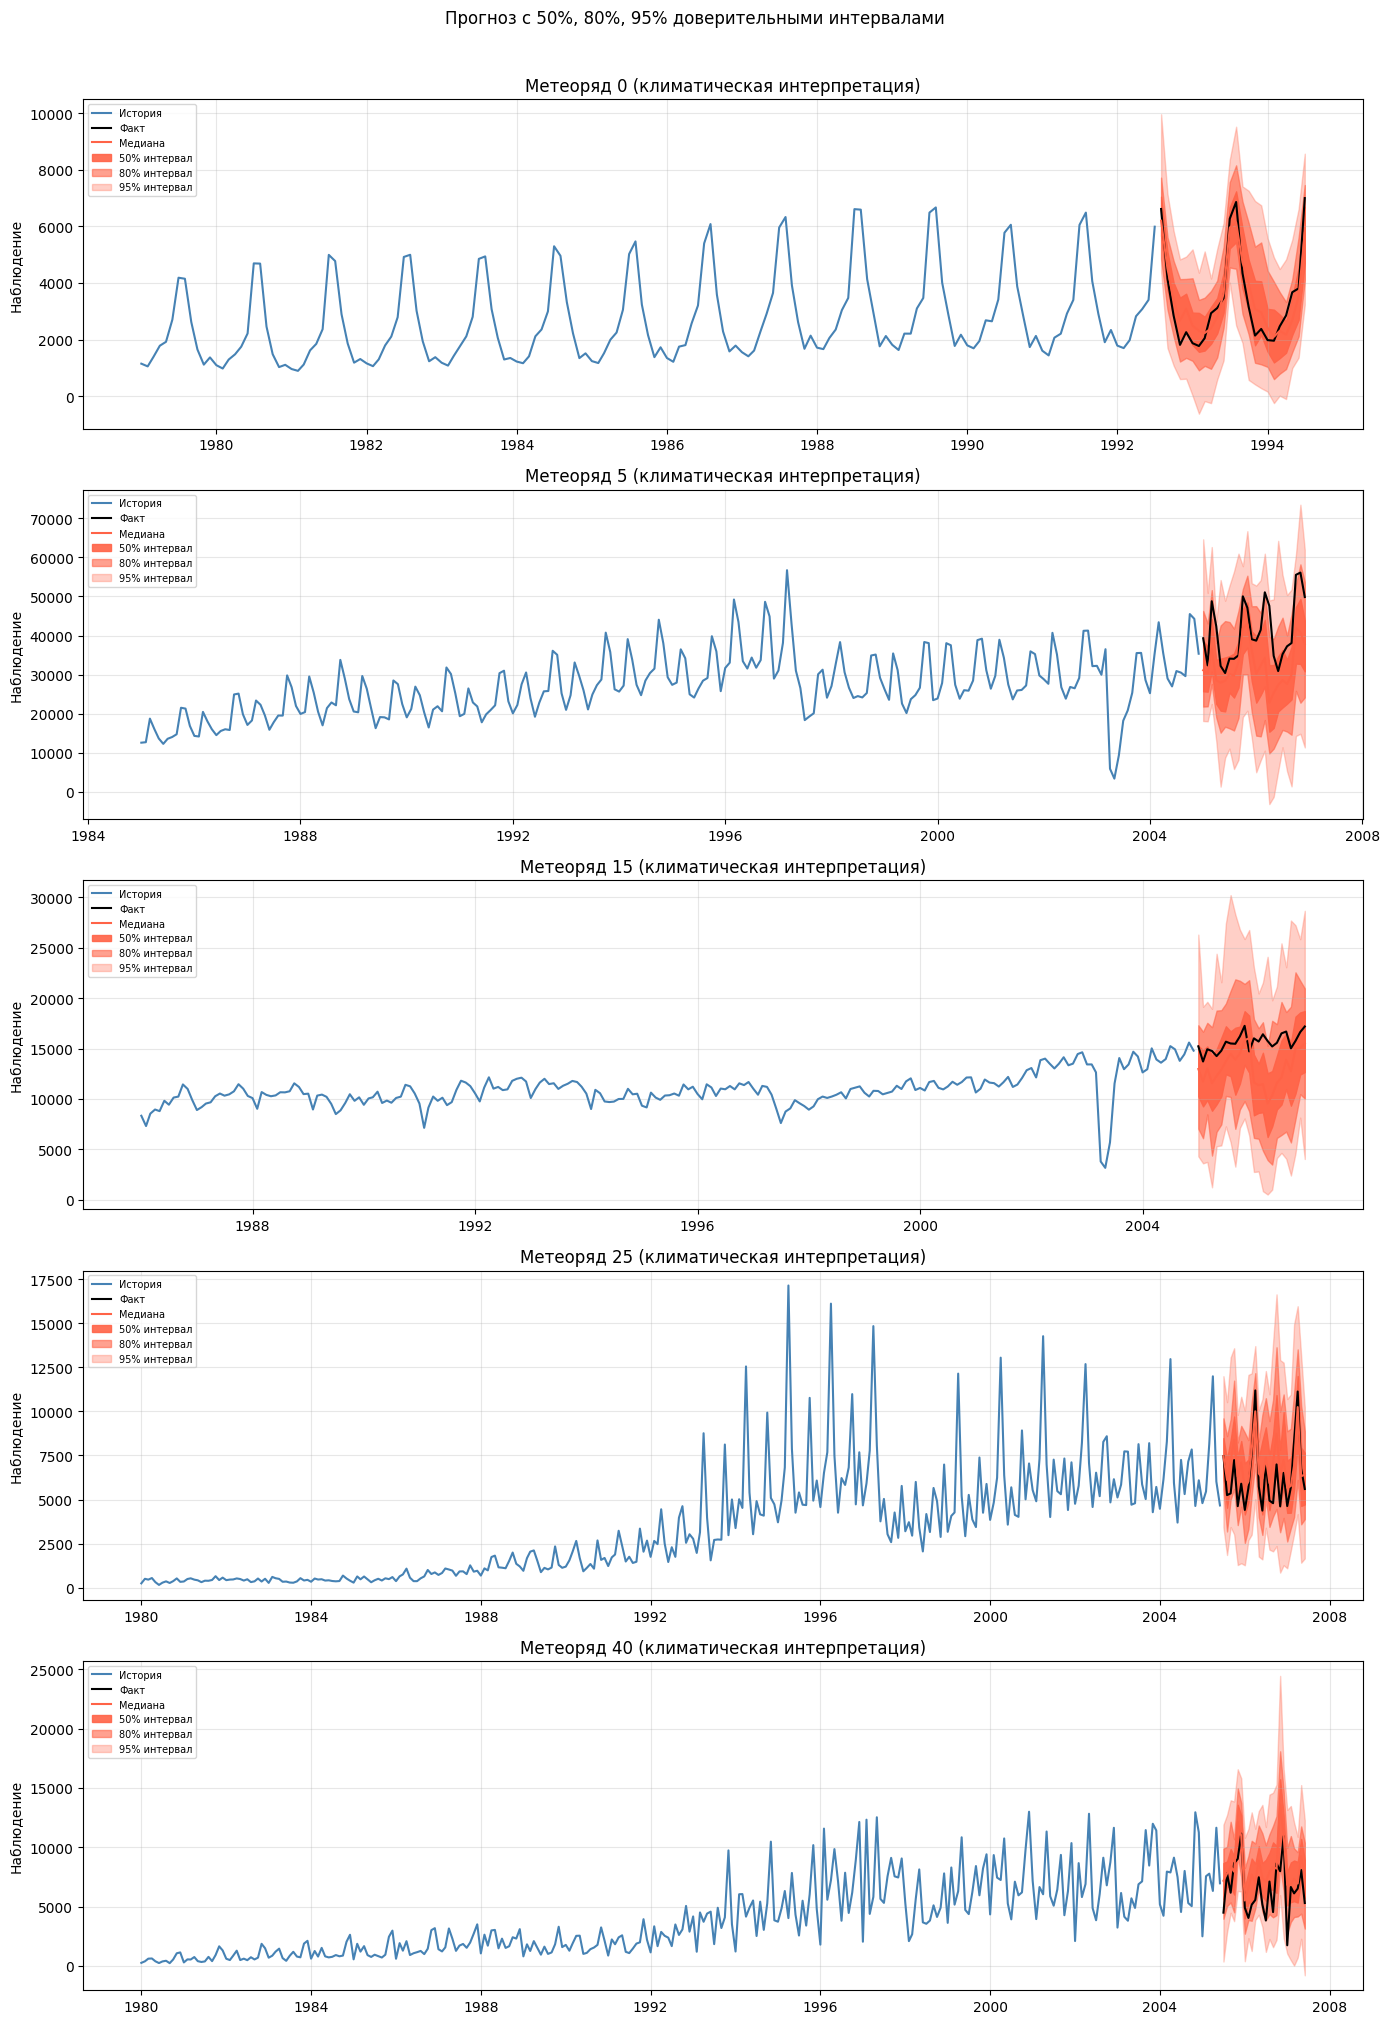

In [26]:
def plot_forecast_multi_ci(ts_index, ax=None):
    """Прогноз с 50%, 80%, 95% доверительными интервалами."""
    ts = test_dataset[ts_index]
    forecast_samples = forecasts[ts_index]

    start_raw = ts[FieldName.START]
    start_str = (
        start_raw.strftime("%Y-%m-%d")
        if hasattr(start_raw, "strftime")
        else str(start_raw)
    )
    start = pd.Period(start_str, freq=freq)

    n_total = len(ts["target"])
    index = pd.period_range(start, periods=n_total, freq=freq)

    context = ts["target"][:-prediction_length]
    actual = ts["target"][-prediction_length:]
    median = np.median(forecast_samples, axis=0)

    q025 = np.percentile(forecast_samples, 2.5, axis=0)
    q10  = np.percentile(forecast_samples, 10, axis=0)
    q25  = np.percentile(forecast_samples, 25, axis=0)
    q75  = np.percentile(forecast_samples, 75, axis=0)
    q90  = np.percentile(forecast_samples, 90, axis=0)
    q975 = np.percentile(forecast_samples, 97.5, axis=0)

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))

    t_hist = index[:-prediction_length].to_timestamp()
    t_pred = index[-prediction_length:].to_timestamp()

    ax.plot(t_hist, context, color="steelblue", linewidth=1.5, label="История")
    ax.plot(t_pred, actual, color="black", linewidth=1.5, label="Факт")
    ax.plot(t_pred, median, color="tomato", linewidth=1.5, label="Медиана")
    
    ax.fill_between(
        t_pred, q25, q75,
        alpha=0.9, color="tomato", label="50% интервал",
    )
    ax.fill_between(
        t_pred, q10, q90,
        alpha=0.6, color="tomato", label="80% интервал",
    )
    ax.fill_between(
        t_pred, q025, q975,
        alpha=0.3, color="tomato", label="95% интервал",
    )
    
    ax.set_title(f"Метеоряд {ts_index} (климатическая интерпретация)")
    ax.set_ylabel("Наблюдение")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

vis_indices = [0, 5, 15, 25, 40]
fig, axes = plt.subplots(len(vis_indices), 1, figsize=(14, 4 * len(vis_indices)))

for ax, idx in zip(axes, vis_indices):
    plot_forecast_multi_ci(idx, ax=ax)

plt.suptitle("Прогноз с 50%, 80%, 95% доверительными интервалами", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [27]:
q025_all = np.percentile(forecasts, 2.5,  axis=1)
q10_all  = np.percentile(forecasts, 10,  axis=1)
q25_all  = np.percentile(forecasts, 25,  axis=1)
q75_all  = np.percentile(forecasts, 75,  axis=1)
q90_all  = np.percentile(forecasts, 90,  axis=1)
q975_all = np.percentile(forecasts, 97.5, axis=1)

width_50 = np.mean(q75_all  - q25_all,  axis=1)
width_80 = np.mean(q90_all  - q10_all,  axis=1)
width_95 = np.mean(q975_all  - q025_all,  axis=1)

print("Средняя ширина доверительных интервалов (по всем рядам):")
print(f"  50%-й интервал: {np.mean(width_50):.2f}")
print(f"  80%-й интервал: {np.mean(width_80):.2f}")
print(f"  95%-й интервал: {np.mean(width_95):.2f}")

Средняя ширина доверительных интервалов (по всем рядам):
  50%-й интервал: 21053.77
  80%-й интервал: 42640.68
  95%-й интервал: 72872.44


Ряд с максимальной неопределенностью: 13
Ширина 80%-го интервала: 607951.06


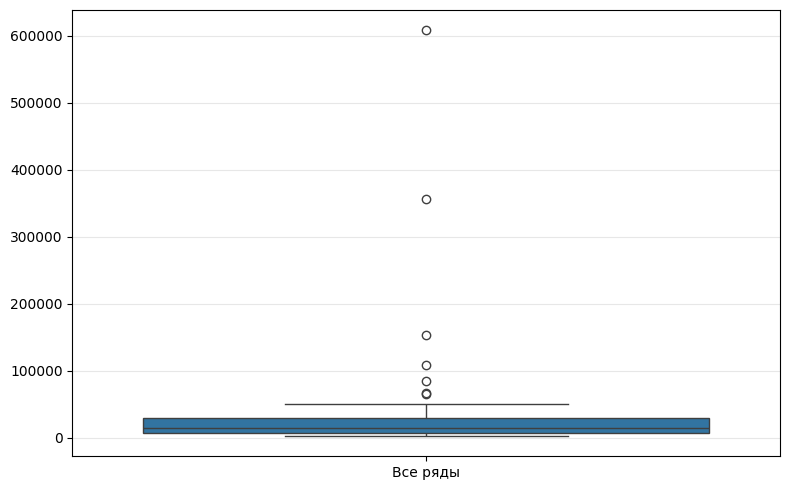

In [28]:
max_unc_idx = int(np.argmax(width_80))
print(f"Ряд с максимальной неопределенностью: {max_unc_idx}")
print(f"Ширина 80%-го интервала: {width_80[max_unc_idx]:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(width_80)

ax.set_xticklabels(["Все ряды"])
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

MASE  -- среднее: 1.823, медиана: 1.537
sMAPE -- среднее: 0.091, медиана: 0.082


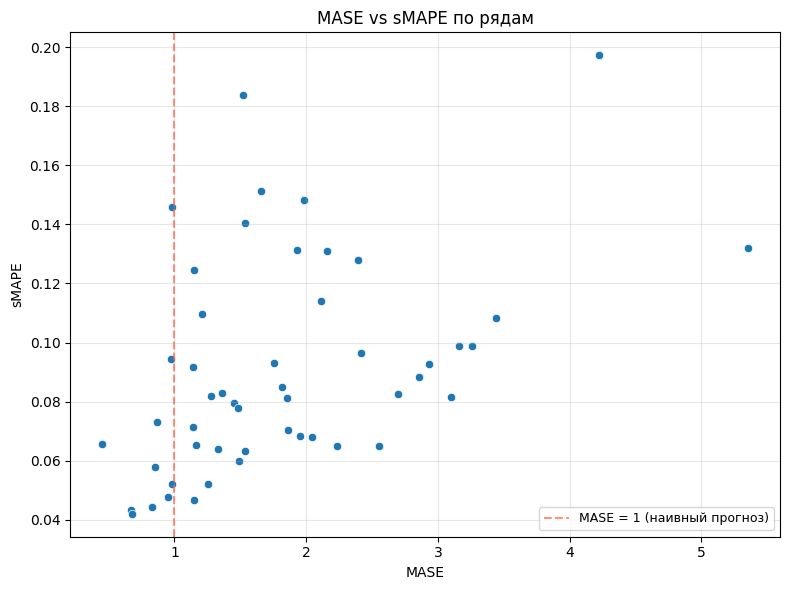

In [29]:
def compute_smape(predictions, references) -> float:
    """Symmetric Mean Absolute Percentage Error."""
    predictions = np.array(predictions, dtype=float)
    references = np.array(references, dtype=float)

    denominator = np.abs(predictions) + np.abs(references)

    mask = denominator > 0
    if mask.sum() == 0:
        return 0.0

    return float(np.mean(np.abs(predictions[mask] - references[mask]) / denominator[mask]))

smape_values = []
for item_id in range(len(raw_test)):
    target = np.array(raw_test[item_id]["target"], dtype=float)

    ground_truth = target[-prediction_length:]
    pred = forecast_median[item_id]

    smape_values.append(compute_smape(pred, ground_truth))


print(f"MASE  -- среднее: {np.mean(mase_values):.3f}, медиана: {np.median(mase_values):.3f}")
print(f"sMAPE -- среднее: {np.mean(smape_values):.3f}, медиана: {np.median(smape_values):.3f}")

fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    x=mase_values,
    y=smape_values,
)

ax.set_xlabel("MASE")
ax.set_ylabel("sMAPE")
ax.set_title("MASE vs sMAPE по рядам")
ax.axvline(1.0, color="tomato", linestyle="--", alpha=0.7, label="MASE = 1 (наивный прогноз)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Интерпретация результатов (климатический контекст):**

В климатологии широкий доверительный интервал означает высокую неопределенность
прогноза. Это может быть связано с непредсказуемыми экстремальными событиями
(аномальная жара, холодные волны, засухи).

Экстремальные значения (хвосты распределения Стьюдента) соответствуют
маловероятным, но возможным экстремальным погодным событиям. Распределение
Student-t с тяжелыми хвостами лучше моделирует такие редкие события,
чем нормальное распределение.

Scatter-plot MASE vs sMAPE показывает корреляцию метрик: ряды, трудные
для прогнозирования по одной метрике, как правило, трудны и по другой.
Точки выше MASE = 1 — это ряды, где модель хуже наивного сезонного прогноза
(повторения значений годичной давности). В климатологии MASE > 1 означает,
что модель хуже простого повторения прошлогодней температуры.

### Метрика pass@k для автоформализации

In [ ]:
from math import comb

# Математические утверждения (mock-данные)
problems = [
    {
        "id": "algebra_square_completion",
        "statement": "x^2 + 8x + y^2 - 6y = 0 implies (x+4)^2 + (y-3)^2 = 25",
        "latex": r"$x^2+8x+y^2-6y=0 \Rightarrow (x+4)^2+(y-3)^2=25$",
        "n_attempts": 10,
        "n_correct": 7,
    },
    {
        "id": "algebra_function_composition",
        "statement": "f(x) = 2x+1, g(x) = 3x-2, then f(g(3)) = 15",
        "latex": r"$f(x)=2x+1,\; g(x)=3x-2 \Rightarrow f(g(3))=15$",
        "n_attempts": 10,
        "n_correct": 9,
    },
    {
        "id": "algebra_linear_system",
        "statement": "2f + 3z = 1 and f - z = -17 imply f = -10 and z = 7",
        "latex": r"$2f+3z=1,\; f-z=-17 \Rightarrow f=-10,\; z=7$",
        "n_attempts": 10,
        "n_correct": 8,
    },
    {
        "id": "number_theory_divisibility",
        "statement": "For all n in N: n^3 - n is divisible by 6",
        "latex": r"$\forall n\in\mathbb{N}:\; 6 \mid n^3-n$",
        "n_attempts": 10,
        "n_correct": 4,
    },
    {
        "id": "algebra_inequality",
        "statement": "For a,b >= 0: (a+b)/2 >= sqrt(ab)",
        "latex": r"$a,b\geq 0 \Rightarrow \frac{a+b}{2}\geq\sqrt{ab}$",
        "n_attempts": 10,
        "n_correct": 5,
    },
    {
        "id": "geometry_triangle_angles",
        "statement": "Sum of angles in any triangle equals 180 degrees",
        "latex": r"$\alpha+\beta+\gamma=180^\circ$",
        "n_attempts": 10,
        "n_correct": 3,
    },
    {
        "id": "calculus_derivative_power",
        "statement": "d/dx(x^n) = n*x^(n-1) for n in N",
        "latex": r"$\frac{d}{dx}x^n = nx^{n-1}$",
        "n_attempts": 10,
        "n_correct": 2,
    },
    {
        "id": "combinatorics_binomial",
        "statement": "C(n,k) = C(n, n-k)",
        "latex": r"$\binom{n}{k}=\binom{n}{n-k}$",
        "n_attempts": 10,
        "n_correct": 6,
    },
]

print(f"Количество задач: {len(problems)}")
for p in problems:
    print(f"  {p['id']}: {p['n_correct']}/{p['n_attempts']} верных попыток")

Количество задач: 8
  algebra_square_completion: 7/10 верных попыток
  algebra_function_composition: 9/10 верных попыток
  algebra_linear_system: 8/10 верных попыток
  number_theory_divisibility: 4/10 верных попыток
  algebra_inequality: 5/10 верных попыток
  geometry_triangle_angles: 3/10 верных попыток
  calculus_derivative_power: 2/10 верных попыток
  combinatorics_binomial: 6/10 верных попыток


In [31]:
def compute_pass_at_k(n: int, c: int, k: int) -> float:
    """
    Вычисляет pass@k.

    Параметры:
        n -- число попыток (семплов)
        c -- число верных попыток
        k -- размер выборки

    Формула:
        pass@k = 1 - C(n-c, k) / C(n, k)

    Если k > n, возвращает 1.0 если c > 0, иначе 0.0.
    Если n - c < k, то C(n-c, k) = 0, и pass@k = 1.0.
    """
    if k > n:
        return 1.0 if c > 0 else 0.0
    if n - c < k:
        return 1.0
    return 1 - comb(n-c, k) / comb(n, k)

print("Проверка формулы:")
print(f"  pass@1 при n=10, c=5: {compute_pass_at_k(10, 5, 1):.4f}  (ожидаем 0.5)")
print(f"  pass@1 при n=10, c=10: {compute_pass_at_k(10, 10, 1):.4f} (ожидаем 1.0)")
print(f"  pass@1 при n=10, c=0: {compute_pass_at_k(10, 0, 1):.4f}  (ожидаем 0.0)")
print(f"  pass@3 при n=10, c=5: {compute_pass_at_k(10, 5, 3):.4f}  (ожидаем ~0.917)")

Проверка формулы:
  pass@1 при n=10, c=5: 0.5000  (ожидаем 0.5)
  pass@1 при n=10, c=10: 1.0000 (ожидаем 1.0)
  pass@1 при n=10, c=0: 0.0000  (ожидаем 0.0)
  pass@3 при n=10, c=5: 0.9167  (ожидаем ~0.917)


In [32]:
k_values = [1, 3, 5]
results_table = []

for p in problems:
    row = {"id": p["id"]}
    for k in k_values:
        row[f"pass@{k}"] = compute_pass_at_k(
            n=p["n_attempts"],
            c=p["n_correct"],
            k=k,
        )
    results_table.append(row)

print(f"{"Задача":<35s}", end="")
for k in k_values:
    print(f"  pass@{k}", end="")
print()
print("-" * 60)

for row in results_table:
    print(
        f"{row["id"]:<35s}  "
        f"{row["pass@1"]:<6.4f}  "
        f"{row["pass@3"]:<6.4f}  "
        f"{row["pass@5"]:<6.4f}"
    )

print("\n--- Среднее pass@k по всем задачам ---")
for k in k_values:
    values = [row[f"pass@{k}"] for row in results_table]
    mean_pk = np.mean(values)
    print(f"  Среднее pass@{k} = {mean_pk:.4f}")

Задача                               pass@1  pass@3  pass@5
------------------------------------------------------------
algebra_square_completion            0.7000  0.9917  1.0000
algebra_function_composition         0.9000  1.0000  1.0000
algebra_linear_system                0.8000  1.0000  1.0000
number_theory_divisibility           0.4000  0.8333  0.9762
algebra_inequality                   0.5000  0.9167  0.9960
geometry_triangle_angles             0.3000  0.7083  0.9167
calculus_derivative_power            0.2000  0.5333  0.7778
combinatorics_binomial               0.6000  0.9667  1.0000

--- Среднее pass@k по всем задачам ---
  Среднее pass@1 = 0.5500
  Среднее pass@3 = 0.8688
  Среднее pass@5 = 0.9583


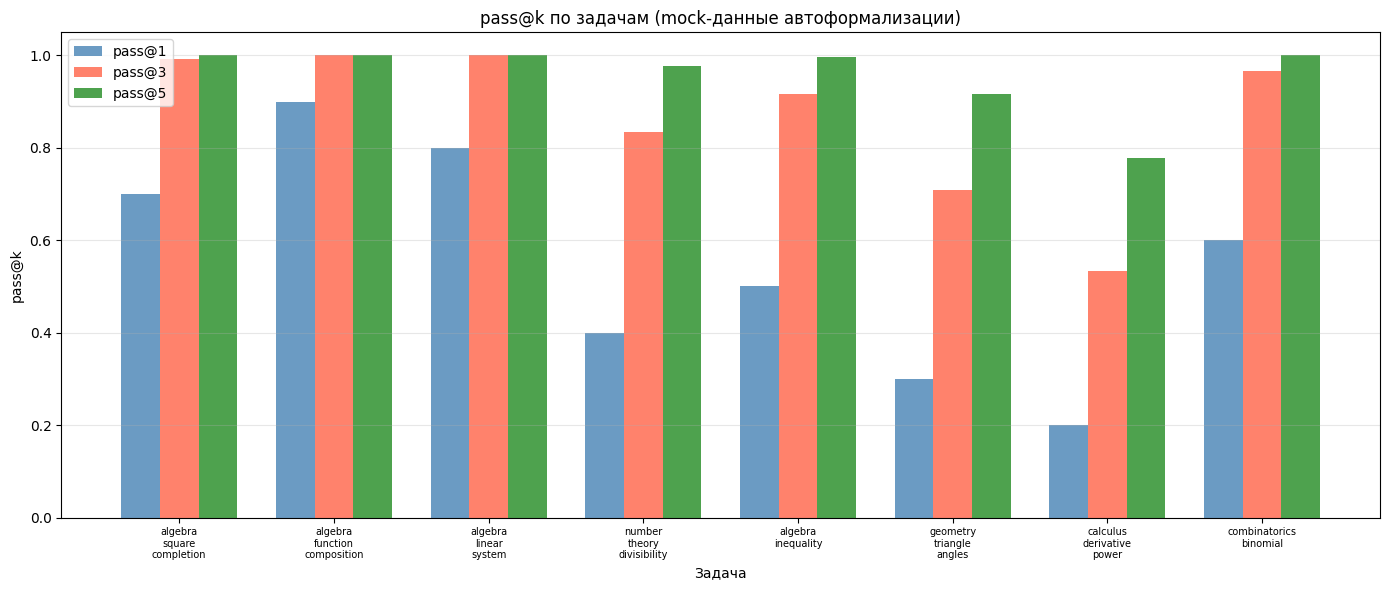

In [33]:
n_problems = len(results_table)
x = np.arange(n_problems)
width = 0.25
colors = ["steelblue", "tomato", "forestgreen"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, k in enumerate(k_values):
    vals = [row[f"pass@{k}"] for row in results_table]
    ax.bar(x + i * width, vals, width, label=f"pass@{k}", color=colors[i], alpha=0.8)

ax.set_xlabel("Задача")
ax.set_ylabel("pass@k")
ax.set_title("pass@k по задачам (mock-данные автоформализации)")
ax.set_xticks(x + width)

labels_short = [p["id"].replace("_", "\n") for p in problems]
ax.set_xticklabels(labels_short, fontsize=7, ha="center")

ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [34]:
mock_proof_candidates = {
    "algebra_square_completion": [
        ("nlinarith [sq_nonneg (x+4), sq_nonneg (y-3)]", 0.85, True),
        ("ring", 0.50, False),
        ("linarith", 0.45, False),
        ("norm_num", 0.40, False),
        ("simp", 0.35, False),
    ],
    "algebra_function_composition": [
        ("simp only [h0, h1]; norm_num", 0.90, True),
        ("norm_num", 0.70, True),
        ("ring", 0.60, False),
        ("omega", 0.30, False),
        ("decide", 0.25, False),
    ],
    "algebra_linear_system": [
        ("constructor <;> linarith", 0.88, True),
        ("omega", 0.55, False),
        ("linarith", 0.50, False),
        ("norm_num", 0.40, False),
        ("ring", 0.35, False),
    ],
    "number_theory_divisibility": [
        ("omega", 0.60, False),
        ("norm_num", 0.55, False),
        ("decide", 0.50, True),
        ("ring", 0.40, False),
        ("simp", 0.35, False),
    ],
    "algebra_inequality": [
        ("nlinarith [sq_nonneg (a - b)]", 0.80, True),
        ("linarith", 0.50, False),
        ("positivity", 0.45, False),
        ("norm_num", 0.40, False),
        ("ring", 0.30, False),
    ],
    "geometry_triangle_angles": [
        ("linarith", 0.55, False),
        ("omega", 0.50, False),
        ("norm_num", 0.48, False),
        ("simp [angle_sum]", 0.45, True),
        ("ring", 0.30, False),
    ],
    "calculus_derivative_power": [
        ("induction n with d hd", 0.40, False),
        ("simp [pow_succ, mul_comm]", 0.38, True),
        ("ring", 0.35, False),
        ("norm_num", 0.30, False),
        ("omega", 0.25, False),
    ],
    "combinatorics_binomial": [
        ("simp [Nat.choose_symm]", 0.85, True),
        ("omega", 0.50, False),
        ("norm_num", 0.45, False),
        ("ring", 0.40, False),
        ("decide", 0.35, False),
    ],
}


def mock_greedy_search(candidates):
    """Greedy: выбирает кандидата с наивысшей оценкой (score = element[1])."""
    return max(candidates, key=lambda x: x[1])

def mock_beam_search(candidates, beam_width=3):
    """Beam search: проверяет beam_width лучших кандидатов, возвращает первый верный."""
    sorted_cand = sorted(candidates, key=lambda x: x[1], reverse=True)
    top_beam = sorted_cand[:beam_width]

    for cand in top_beam:
        if cand[2]:
            return cand

    return top_beam[0]

print(f"{'Задача':<35s}  {'Greedy':<12s}  {'Beam(3)':<12s}")
print("-" * 62)

greedy_correct = 0
beam_correct = 0

for p in problems:
    pid = p["id"]
    
    if pid not in mock_proof_candidates:
        continue

    cands = mock_proof_candidates[pid]

    g = mock_greedy_search(cands)
    b = mock_beam_search(cands, beam_width=3)

    g_status = "ВЕРНО" if g[2] else "ОШИБКА"
    b_status = "ВЕРНО" if b[2] else "ОШИБКА"

    greedy_correct += int(g[2])
    beam_correct += int(b[2])

    print(f"{pid:<35s}  {g_status:<12s}  {b_status:<12s}")

n_total = len(mock_proof_candidates)
print(f"\nGreedy pass@1: {greedy_correct}/{n_total} = {greedy_correct/n_total:.3f}")
print(f"Beam(3) pass@1: {beam_correct}/{n_total} = {beam_correct/n_total:.3f}")

Задача                               Greedy        Beam(3)     
--------------------------------------------------------------
algebra_square_completion            ВЕРНО         ВЕРНО       
algebra_function_composition         ВЕРНО         ВЕРНО       
algebra_linear_system                ВЕРНО         ВЕРНО       
number_theory_divisibility           ОШИБКА        ВЕРНО       
algebra_inequality                   ВЕРНО         ВЕРНО       
geometry_triangle_angles             ОШИБКА        ОШИБКА      
calculus_derivative_power            ОШИБКА        ВЕРНО       
combinatorics_binomial               ВЕРНО         ВЕРНО       

Greedy pass@1: 5/8 = 0.625
Beam(3) pass@1: 7/8 = 0.875


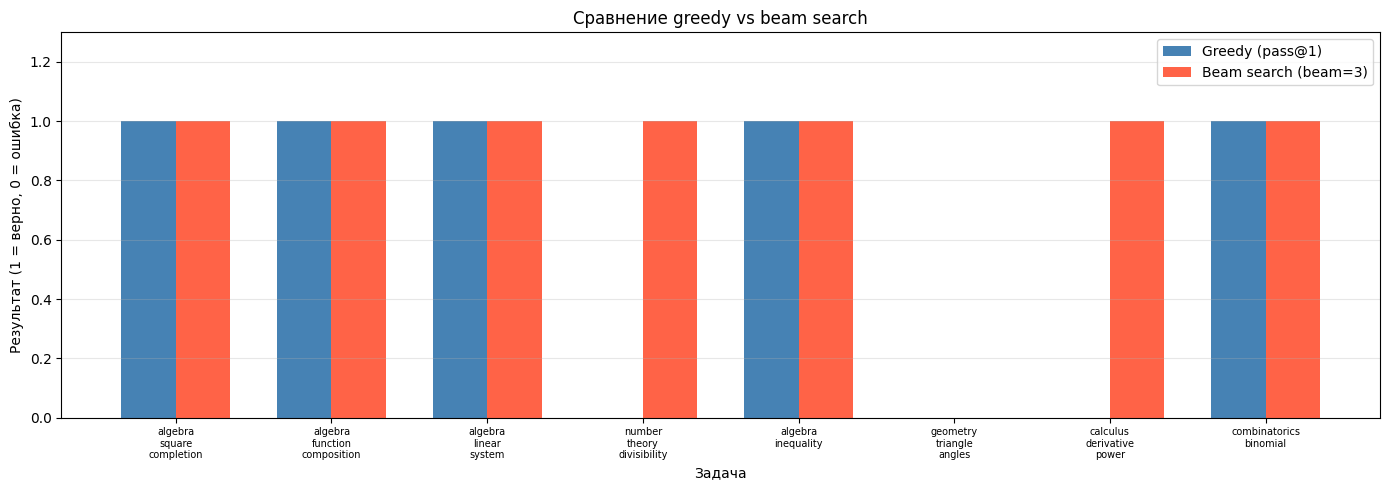

In [35]:
greedy_results = []
beam_results = []

for p in problems:
    pid = p["id"]
    cands = mock_proof_candidates.get(pid, [])
    if not cands:
        greedy_results.append(0)
        beam_results.append(0)
        continue

    g = mock_greedy_search(cands)
    b = mock_beam_search(cands, beam_width=3)
    greedy_results.append(int(g[2]))
    beam_results.append(int(b[2]))

x = np.arange(len(problems))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))

bars1 = ax.bar(
    x - width/2, greedy_results, width,
    label="Greedy (pass@1)", color="steelblue",
)
bars2 = ax.bar(
    x + width/2, beam_results, width,
    label="Beam search (beam=3)", color="tomato",
)

ax.set_xlabel("Задача")
ax.set_ylabel("Результат (1 = верно, 0 = ошибка)")
ax.set_title("Сравнение greedy vs beam search")
ax.set_xticks(x)

labels_short2 = [p["id"].replace("_", "\n") for p in problems]
ax.set_xticklabels(labels_short2, fontsize=7, ha="center")

ax.legend()
ax.set_ylim(0, 1.3)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Интерпретация результатов:**

1. **pass@k возрастает с k** для всех задач: чем больше попыток мы рассматриваем,
   тем выше вероятность найти хотя бы одно верное доказательство.

2. **Задачи с высоким n_correct** (алгебра, композиция функций) имеют высокий pass@1,
   что означает, что модель уверенно генерирует верные доказательства.

3. **Задачи с низким n_correct** (дифференцирование, геометрия) имеют низкий pass@1,
   но значительно более высокий pass@5, здесь стратегия множественного семплирования
   критически важна.

4. **Beam search vs greedy:** beam search проверяет несколько лучших кандидатов,
   что увеличивает вероятность найти верное доказательство. На задачах, где верная
   тактика не имеет наивысшую оценку (например, geometry_triangle_angles),
   beam search находит решение, а greedy — нет.

5. **Аналогия с бенчмарком miniF2F:** среднее pass@k по всем задачам — это стандартная
   метрика оценки систем автоформализации. DeepSeek-Prover-V2 достигает pass@1 = 58.6%
   на miniF2F-test (non-CoT).